In [1]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=20, n_informative=5, n_redundant=5, random_state=42)
df_features = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

selector = SelectKBest(f_classif, k=10)
X_new = selector.fit_transform(X, y)

selected_features_indices = selector.get_support(indices=True)
selected_feature_names = df_features.columns[selected_features_indices]

print("Original number of features:", X.shape[1])
print("Number of selected features:", X_new.shape[1])
print("Selected feature names:", selected_feature_names.tolist())

Original number of features: 20
Number of selected features: 10
Selected feature names: ['feature_1', 'feature_2', 'feature_3', 'feature_7', 'feature_10', 'feature_11', 'feature_12', 'feature_15', 'feature_18', 'feature_19']


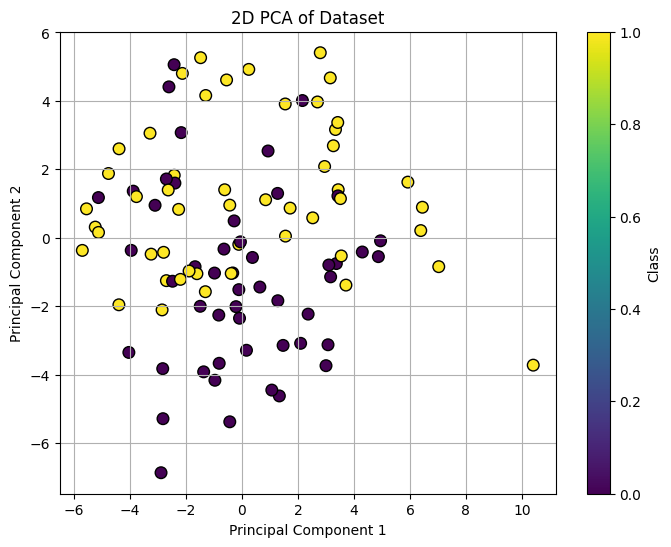

Original data shape: (100, 20)
Reduced data shape (PCA): (100, 2)


In [2]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=70)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA of Dataset')
plt.colorbar(label='Class')
plt.grid(True)
plt.show()

print("Original data shape:", X.shape)
print("Reduced data shape (PCA):", X_pca.shape)